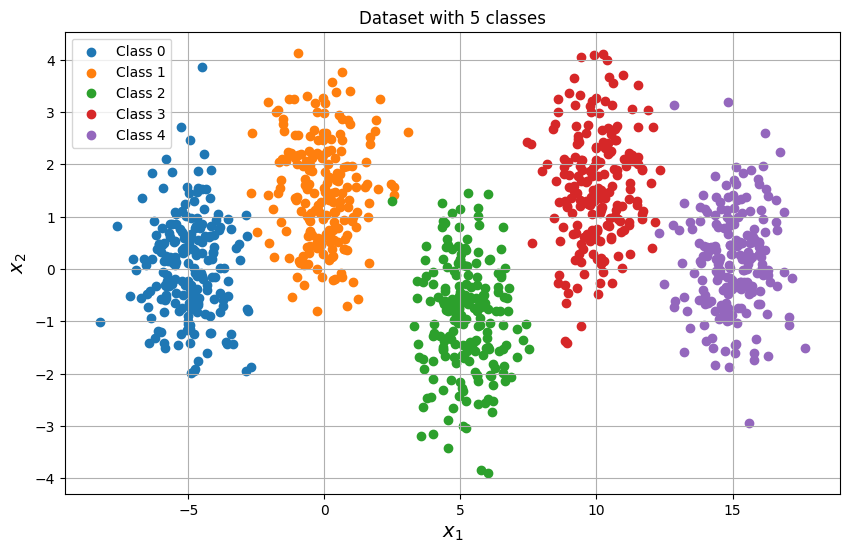

Best learning rate found: 0.9

One-vs-Rest Approach:

Training classifier for Class 0 vs Rest


/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))
/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))
/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))


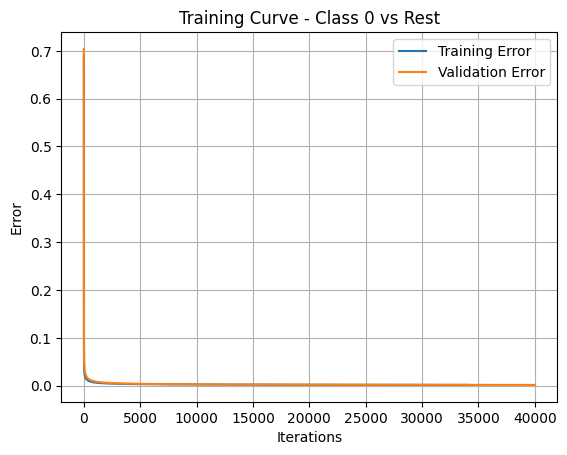


Training classifier for Class 1 vs Rest


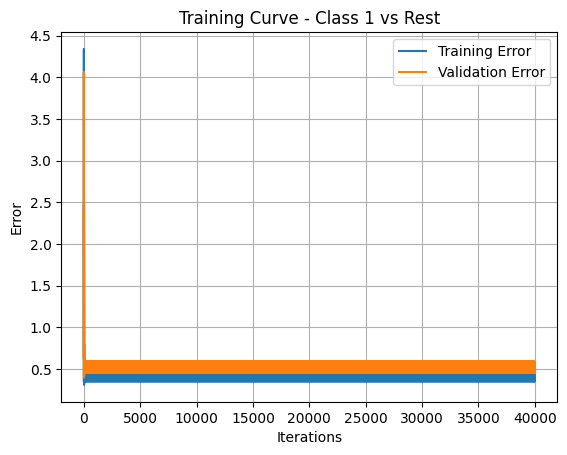


Training classifier for Class 2 vs Rest


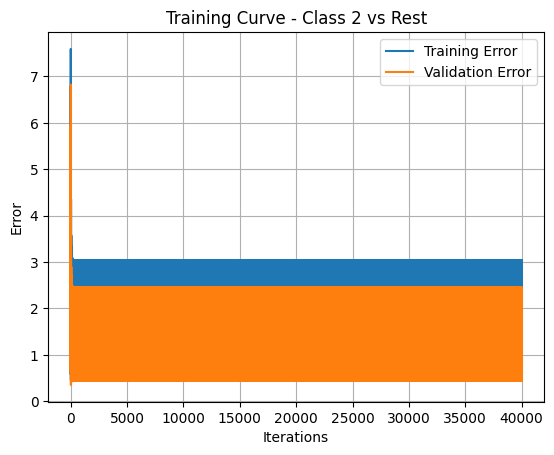


Training classifier for Class 3 vs Rest


/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))


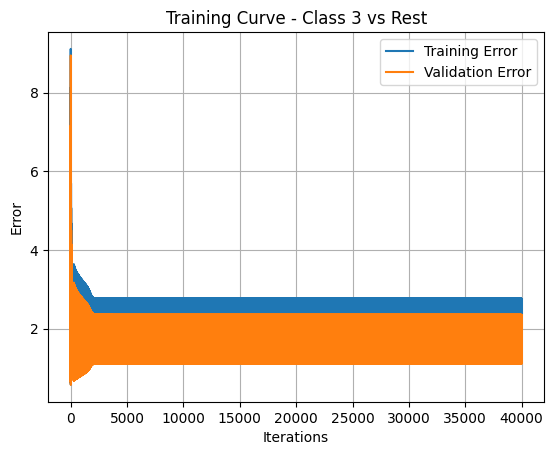


Training classifier for Class 4 vs Rest


/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))


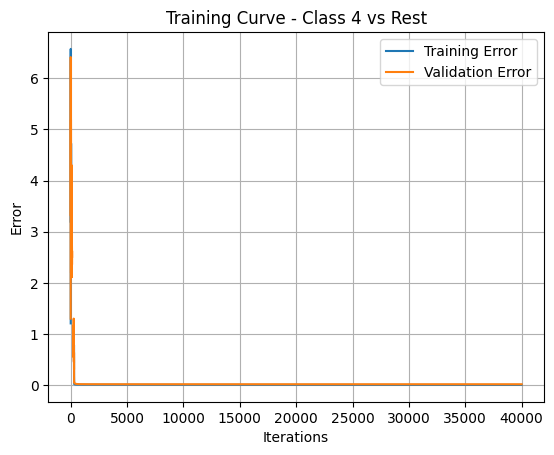


Confusion Matrix (One-vs-Rest):


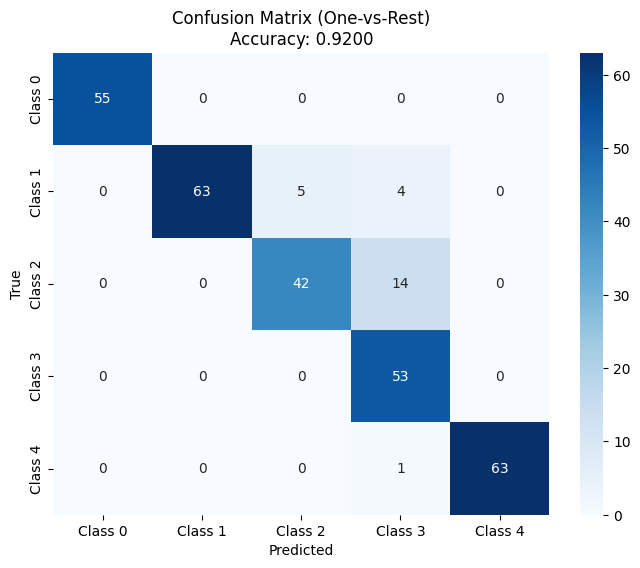


One-vs-One Approach:

Training classifier for Class 0 vs Class 1


/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))
/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))
/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))
/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))


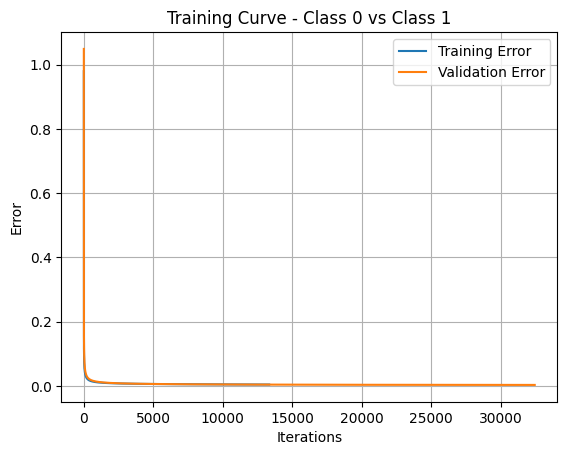


Training classifier for Class 0 vs Class 2


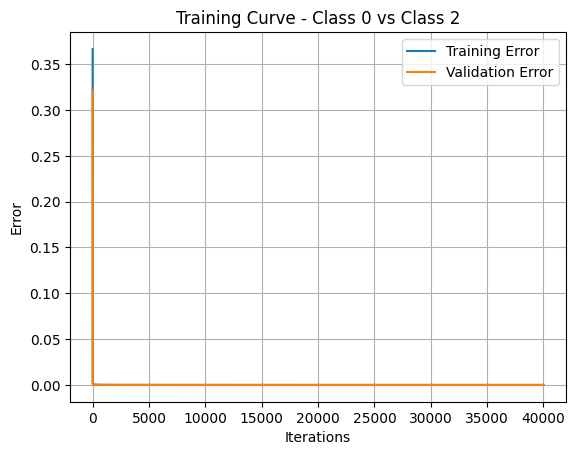


Training classifier for Class 0 vs Class 3


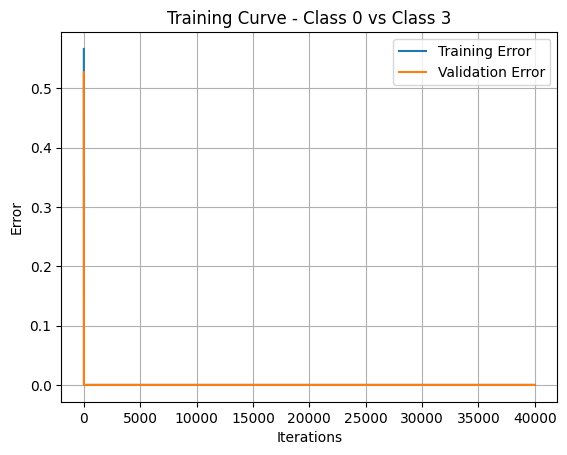


Training classifier for Class 0 vs Class 4


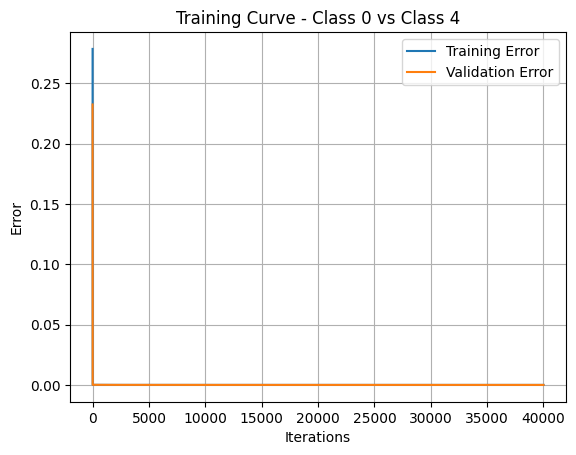


Training classifier for Class 1 vs Class 2


/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))
/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))
/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))
/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))


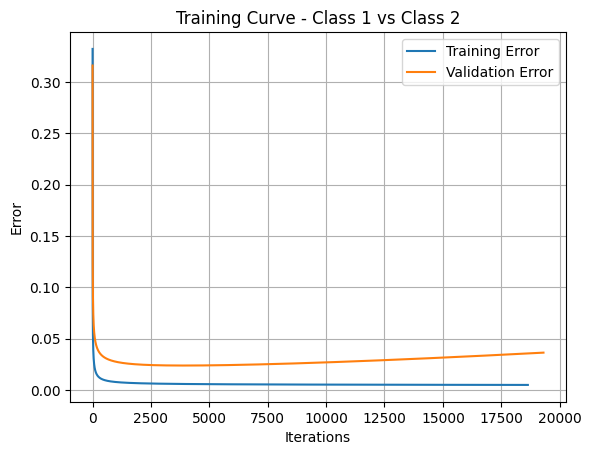


Training classifier for Class 1 vs Class 3


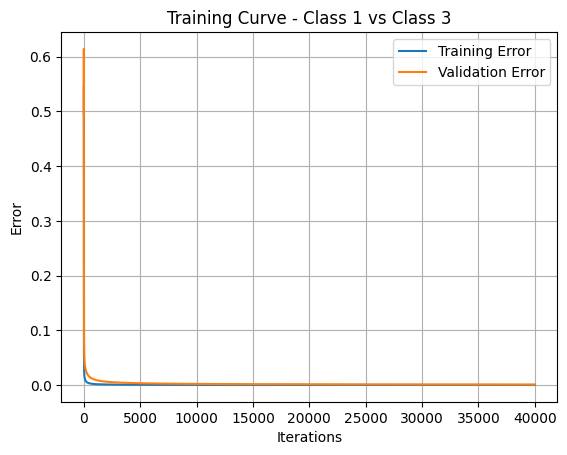


Training classifier for Class 1 vs Class 4


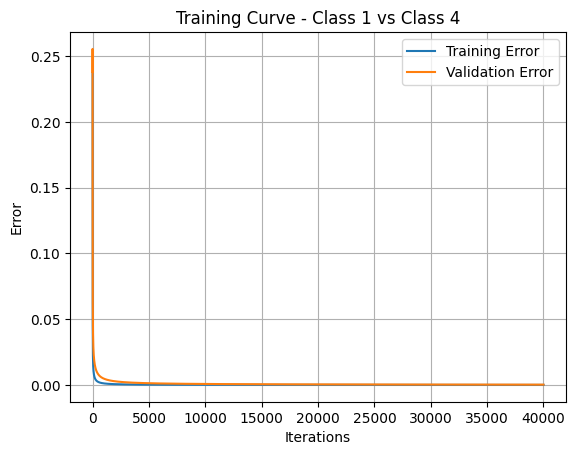


Training classifier for Class 2 vs Class 3


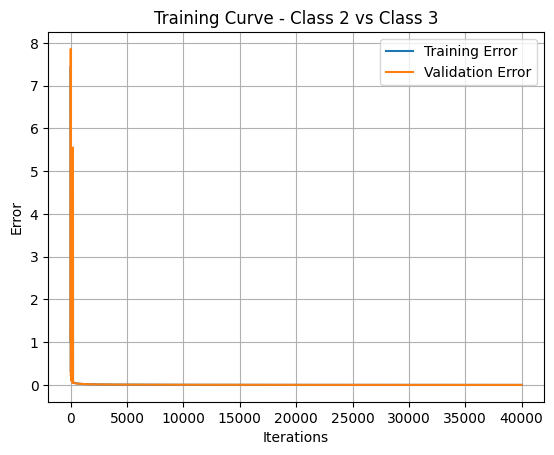


Training classifier for Class 2 vs Class 4


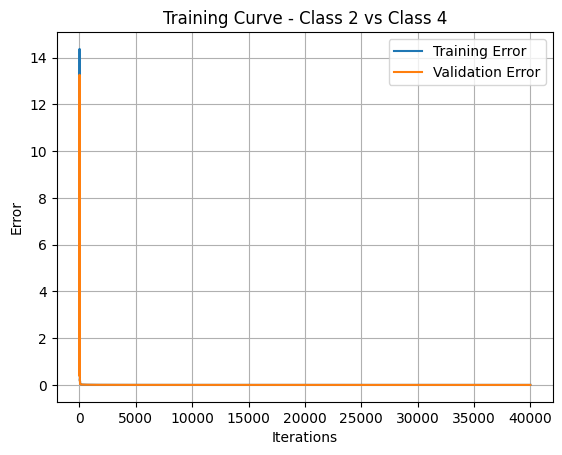


Training classifier for Class 3 vs Class 4


/tmp/ipython-input-3-1040023500.py:33: RuntimeWarning: divide by zero encountered in log
  error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))


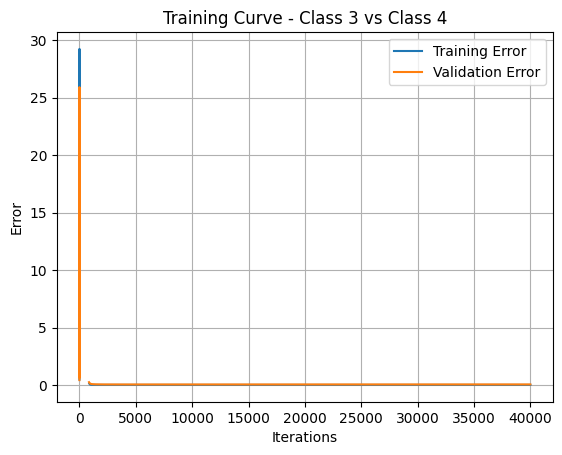


Confusion Matrix (One-vs-One):


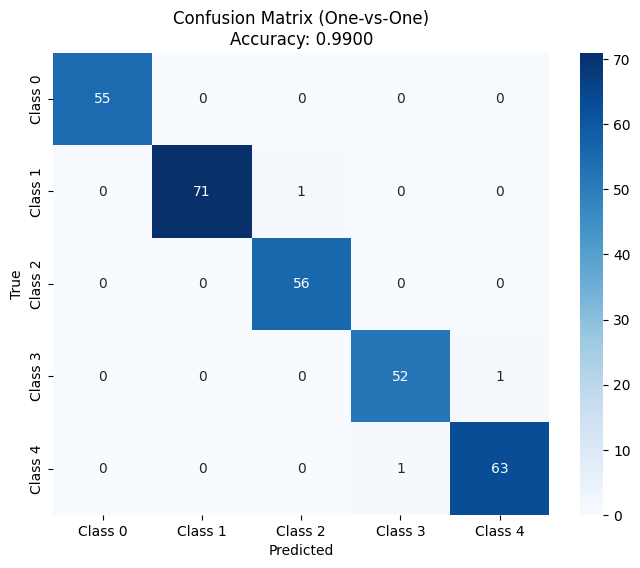


Comparison of Approaches:
One-vs-Rest Accuracy: 0.9200
One-vs-One Accuracy: 0.9900
One-vs-One performed better for this dataset.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.special import expit
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score, confusion_matrix

# Reset PN sequence generator
seed = 42
np.random.seed(seed)

class LogisticRegressor:
    '''Class implementing the Logistic Regressor.'''

    def predict_proba(self, x, a):
        '''Probability estimates. Implements the hypothesis function.'''
        h = expit(x.dot(a))
        return h

    def predict(self, x, a):
        '''Predict class labels for samples in X.'''
        h = self.predict_proba(x, a)
        c = np.zeros((len(h), 1))
        for i in range(0, len(h)):
            if h[i] >= 0.5:
                c[i,0] = 1.0
        return c

    def error_function(self, x, y, a):
        '''Calculate the average error.'''
        h = self.predict_proba(x, a)
        error = -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1-y).T.dot(np.log((1-h))))
        return error

    def fit(self, x_train, y_train, x_test, y_test, alpha, n_iterations, seed):
        '''Fit the model according to the given training data.'''
        # Reset PN sequence generator
        np.random.seed(seed)

        # Random initialization of parameters
        a = np.random.randn(x_train.shape[1], 1)

        # Create array for storing error values
        Jgd = np.zeros(n_iterations+1)
        Jgd_v = np.zeros(n_iterations+1)

        # Calculate initial error
        Jgd[0] = self.error_function(x_train, y_train, a)
        Jgd_v[0] = self.error_function(x_test, y_test, a)

        # Batch gradient-descent loop
        minimum_val_error = float("inf")
        best_weights = a.copy()
        iteration = 0

        while iteration < n_iterations:
            gradients = -1/len(y_train) * x_train.T.dot(y_train - self.predict_proba(x_train, a))
            a = a - alpha * gradients
            Jgd[iteration+1] = self.error_function(x_train, y_train, a)
            Jgd_v[iteration+1] = self.error_function(x_test, y_test, a)

            # Early-stopping: Store weights for the smallest validation error ever
            if Jgd_v[iteration+1] < minimum_val_error:
                minimum_val_error = Jgd_v[iteration+1]
                best_weights = a.copy()

            iteration += 1

        return best_weights, minimum_val_error, iteration, Jgd, Jgd_v

# Generate dataset with 5 classes
M = 1000
centers = [[-5, 0], [0, 1.5], [5, -1], [10, 1.5], [15, 0]]
X, y = make_blobs(n_samples=M, centers=centers, random_state=seed)

# Plot the dataset
plt.figure(figsize=(10, 6))
for i in range(5):
    idx = np.where(y == i)
    plt.scatter(X[idx, 0], X[idx, 1], label=f'Class {i}')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.title('Dataset with 5 classes')
plt.legend()
plt.grid()
plt.show()

# Add bias term to X
X_with_bias = np.c_[np.ones((X.shape[0], 1)), X]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_with_bias, y, test_size=0.3, random_state=seed)

# Find optimal learning rate
learning_rates = [0.001, 0.01, 0.1, 0.3, 0.5, 0.9]
best_alpha = None
best_error = float('inf')

for alpha in learning_rates:
    lr = LogisticRegressor()
    weights, val_error, _, _, _ = lr.fit(
        X_train, (y_train == 0).astype(int).reshape(-1,1),
        X_test, (y_test == 0).astype(int).reshape(-1,1),
        alpha, 1000, seed)

    if val_error < best_error:
        best_error = val_error
        best_alpha = alpha

print(f"Best learning rate found: {best_alpha}")

# One-vs-Rest (OvR) Approach
print("\nOne-vs-Rest Approach:")

# Train 5 classifiers (one for each class)
classifiers_ovr = []
n_iterations = 40000

for class_idx in range(5):
    print(f"\nTraining classifier for Class {class_idx} vs Rest")

    # Create binary labels for this class
    y_train_binary = (y_train == class_idx).astype(int).reshape(-1,1)
    y_test_binary = (y_test == class_idx).astype(int).reshape(-1,1)

    # Train classifier
    lr = LogisticRegressor()
    weights, val_error, iterations, Jgd, Jgd_v = lr.fit(
        X_train, y_train_binary,
        X_test, y_test_binary,
        best_alpha, n_iterations, seed)

    classifiers_ovr.append((lr, weights))

    # Plot training curve
    plt.figure()
    plt.plot(range(iterations), Jgd[:iterations], label='Training Error')
    plt.plot(range(iterations), Jgd_v[:iterations], label='Validation Error')
    plt.xlabel('Iterations')
    plt.ylabel('Error')
    plt.title(f'Training Curve - Class {class_idx} vs Rest')
    plt.legend()
    plt.grid()
    plt.show()

# Predict function for OvR
def predict_ovr(X, classifiers):
    probabilities = np.zeros((X.shape[0], len(classifiers)))

    for i, (clf, weights) in enumerate(classifiers):
        probabilities[:, i] = clf.predict_proba(X, weights).flatten()

    return np.argmax(probabilities, axis=1)

# Make predictions on test set
y_pred_ovr = predict_ovr(X_test, classifiers_ovr)

# Confusion matrix and accuracy
cm_ovr = confusion_matrix(y_test, y_pred_ovr)
acc_ovr = accuracy_score(y_test, y_pred_ovr)

print("\nConfusion Matrix (One-vs-Rest):")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ovr, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Class {i}' for i in range(5)],
            yticklabels=[f'Class {i}' for i in range(5)])
plt.title(f'Confusion Matrix (One-vs-Rest)\nAccuracy: {acc_ovr:.4f}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# One-vs-One (OvO) Approach
print("\nOne-vs-One Approach:")

# Train classifiers for all pairs of classes
class_pairs = [(i, j) for i in range(5) for j in range(i+1, 5)]
classifiers_ovo = {}

n_iterations = 40000

for pair in class_pairs:
    class_i, class_j = pair
    print(f"\nTraining classifier for Class {class_i} vs Class {class_j}")

    # Get indices for these two classes
    idx = np.where((y_train == class_i) | (y_train == class_j))[0]
    X_train_pair = X_train[idx]
    y_train_pair = (y_train[idx] == class_i).astype(int).reshape(-1,1)

    idx_test = np.where((y_test == class_i) | (y_test == class_j))[0]
    X_test_pair = X_test[idx_test]
    y_test_pair = (y_test[idx_test] == class_i).astype(int).reshape(-1,1)

    # Train classifier
    lr = LogisticRegressor()
    weights, val_error, iterations, Jgd, Jgd_v = lr.fit(
        X_train_pair, y_train_pair,
        X_test_pair, y_test_pair,
        best_alpha, n_iterations, seed)

    classifiers_ovo[pair] = (lr, weights)

    # Plot training curve
    plt.figure()
    plt.plot(range(iterations), Jgd[:iterations], label='Training Error')
    plt.plot(range(iterations), Jgd_v[:iterations], label='Validation Error')
    plt.xlabel('Iterations')
    plt.ylabel('Error')
    plt.title(f'Training Curve - Class {class_i} vs Class {class_j}')
    plt.legend()
    plt.grid()
    plt.show()

# Predict function for OvO
def predict_ovo(X, classifiers, n_classes=5):
    votes = np.zeros((X.shape[0], n_classes))

    for (class_i, class_j), (clf, weights) in classifiers.items():
        pred = clf.predict(X, weights).flatten()

        for idx in range(len(pred)):
            if pred[idx] == 1:
                votes[idx, class_i] += 1
            else:
                votes[idx, class_j] += 1

    return np.argmax(votes, axis=1)

# Make predictions on test set
y_pred_ovo = predict_ovo(X_test, classifiers_ovo)

# Confusion matrix and accuracy
cm_ovo = confusion_matrix(y_test, y_pred_ovo)
acc_ovo = accuracy_score(y_test, y_pred_ovo)

print("\nConfusion Matrix (One-vs-One):")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ovo, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Class {i}' for i in range(5)],
            yticklabels=[f'Class {i}' for i in range(5)])
plt.title(f'Confusion Matrix (One-vs-One)\nAccuracy: {acc_ovo:.4f}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Compare both approaches
print("\nComparison of Approaches:")
print(f"One-vs-Rest Accuracy: {acc_ovr:.4f}")
print(f"One-vs-One Accuracy: {acc_ovo:.4f}")

if acc_ovr > acc_ovo:
    print("One-vs-Rest performed better for this dataset.")
elif acc_ovo > acc_ovr:
    print("One-vs-One performed better for this dataset.")
else:
    print("Both approaches performed equally well.")